In [1]:
%load_ext autoreload
%autoreload 1

In [2]:
import os
import pandas as pd
import numpy as np
import scipy
from scipy.stats import spearmanr

import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib import rc
import seaborn as sns
import Bio.PDB
from scipy import stats
from Bio.PDB import SASA # SASA module won't load from newest version of Biopython for some reason
# import Geometry # Biopython Geometry module still not on main branch

import time
import sys
import glob
sys.path.append('/data/mhoffert/fiererlab/adenylate_kinase_ogt/protein_utils/')
from collections import Counter

import Geometry

from IPython.display import display, clear_output

## Preprocessing steps

Files are now unpacked with a bash script. A parallelized version of the python code calculates contact density and Rosetta is run in a parallelized bash script. see the wiki for details.

```
parallel -j 12 './unpack_structures.sh {}' :::: inds_unpack.txt
```
```
parallel -j 12 './run_rosetta.sh {}' :::: inds_rosetta.txt
```

## Arranging data for plotting

In [3]:
genome2temp = pd.read_csv('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/metric_tables/renamed_files.txt', sep='\t', header=None)
genome2temp = genome2temp.dropna().apply(lambda row: pd.Series(index=['temp', 'genome'],
                                       data=[row[0].split('_bit')[0].split('_temp_')[-1],
                                            row[1].split('/')[-1].split('_closed')[0]]), axis=1)

In [4]:
genome2temp = genome2temp.set_index('genome')['temp']

In [5]:
metrics_df = pd.read_csv('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/metric_tables/20240325_python_metrics.tsv', sep='\t')
metrics_df.head()

,Position,Contacts at 4.5 Å,SASA,uid
0,94.0,11.358289,52.616491,GB_GCA_000376885.1
1,108.0,11.125581,49.464040,GB_GCA_000016765.1
2,119.5,11.289720,49.538232,GB_GCA_000242235.1
3,105.5,11.276190,50.018080,GB_GCA_000283575.1
4,91.0,11.359116,51.483049,GB_GCA_001054945.1


In [6]:
# combine rosetta data
rosetta_files = glob.glob('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/rosetta_out/*_processed_rosetta_out.sc')

In [7]:
rosetta_data = []
for i, r in enumerate(rosetta_files):
    if i % 100 == 0:
        display(i)
        clear_output(wait=True)
    rosetta_data.append(pd.read_csv(r, delim_whitespace=True, skiprows=1, index_col='description'))

9300

In [8]:
rosetta_df = pd.concat(rosetta_data)
rosetta_df.head()

,SCORE:,total_score,avg_deg_4_5,avg_deg_8,avg_sc_nbrs_res_summary,bb_internal_hbonds,bbsc_internal_hbonds,cav_vol,dslf_fa13,fa_atr,...,packstat,polar_sasa,pro_close,rama_prepro,ref,sasa,sc_internal_hbonds,total_cc_contacts,yhh_planarity,secondary_structure
description,,,,,,,,,,,,,,,,,,,,,
GB_GCA_000411155.1_A_processed_0001,SCORE:,-433.888,1.351,10.876,2.716,125.0,23.0,226.760,0.0,-1110.039,...,0.578,4190.758,18.201,11.772,55.580,9931.234,27.0,631.0,0.140,LLLEEEEELLLLLLHHHHHHHHHHHHLLLEEEHHHHHHHHHHLLLH...
GB_GCA_001187505.1_A_processed_0001,SCORE:,-443.850,1.298,10.757,2.727,117.0,22.0,223.269,0.0,-1009.724,...,0.592,4151.519,11.423,-10.415,35.368,9294.481,25.0,564.0,0.076,LEEEEELLLLLLHHHHHHHHHHHHLLLEEEHHHHHHHHHHLLLHHH...
GB_GCA_001184205.1_A_processed_0001,SCORE:,-437.262,1.347,10.812,2.679,132.0,32.0,209.604,0.0,-1210.039,...,0.606,4361.120,19.617,7.042,50.130,10639.826,24.0,661.0,0.069,LEEEEELLLLLLHHHHHHHHHHHHLLLEEEHHHHHHHHHHLLLHHH...
GB_GCA_000376885.1_A_processed_0001,SCORE:,-454.076,1.278,10.765,2.648,124.0,21.0,167.472,0.0,-1068.002,...,0.576,4111.250,8.689,-13.650,39.305,9627.839,21.0,576.0,0.040,LEEEEELLLLLLHHHHHHHHHHHHLLLEEEHHHHHHHHHHLLLHHH...
GB_GCA_000423665.1_A_processed_0001,SCORE:,-474.750,1.330,10.817,2.719,141.0,30.0,338.336,0.0,-1250.547,...,0.566,5163.576,20.205,-10.989,1.885,11168.009,29.0,712.0,0.098,LEEEEEELLLLLLHHHHHHHHHHHHLLLEEEHHHHHHHHHHLLLHH...


In [9]:
# parse rosetta outputs
rosetta_df['genome_id'] = ['_'.join(s.split('_adk')[0].split('_A_pro')[0].split('_')[-3:]) for s in rosetta_df.index] #rosetta_df.index.map(lambda x: x.partition('.')[0])

# make a secondary structure series
secondary_structure = rosetta_df.groupby('genome_id').first()['secondary_structure']

# add rosetta metrics
rosetta_df['%S'] = rosetta_df['secondary_structure'].map(lambda x: x.count('E') / len(x))
rosetta_df['%L'] = rosetta_df['secondary_structure'].map(lambda x: x.count('L') / len(x))
rosetta_df['%H'] = rosetta_df['secondary_structure'].map(lambda x: x.count('H') / len(x))
rosetta_df['length'] = rosetta_df['secondary_structure'].map(len)
rosetta_df['avg_cc_contacts_per_res'] = rosetta_df['total_cc_contacts'] / rosetta_df['length']
rosetta_df = rosetta_df.groupby('genome_id').mean(numeric_only=True)

In [10]:
# rosetta_df['genome'] = rosetta_df.index + '.1'
metrics_df = pd.merge(metrics_df, rosetta_df, left_on='uid', right_index=True)

In [11]:
# add temperature
metrics_df['temp'] = metrics_df['uid'].apply(lambda x: float(genome2temp.loc[x]))

## Arranging databases (ugh)

In [12]:
# get GTDB data
gtdb_md = pd.read_csv('/data/mhoffert/genomes/GTDB_r214.1/bac120_metadata.tsv.gz', sep='\t', index_col=0)

/tmp/ipykernel_1611373/3228881117.py:2: DtypeWarning: Columns (61,63,65,74,82,83) have mixed types. Specify dtype option on import or set low_memory=False.
  gtdb_md = pd.read_csv('/data/mhoffert/genomes/GTDB_r214.1/bac120_metadata.tsv.gz', sep='\t', index_col=0)


In [13]:
base_path = '/data/mhoffert/fiererlab/ogt/results/db/'
gtdb_match_data = pd.concat([pd.read_csv(f'{base_path}{db}_gtdb_matching.tsv', sep='\t', index_col=0).assign(db=db) for db in ['melnikov', 'tempura', 'corkey', 'engqvist']])

# gtdb_match_data.head()

tempura_values = gtdb_match_data[gtdb_match_data.db.eq('tempura')]['original_id'].values
engqvist_values = gtdb_match_data[gtdb_match_data.db.eq('engqvist')]['original_id'].values
melnikov_values = gtdb_match_data[gtdb_match_data.db.eq('melnikov')]['original_id'].values

In [14]:
len(gtdb_match_data['original_id'].unique()), gtdb_match_data['original_id'].shape

(31821, (36090,))

In [15]:
gtdb_match_data = pd.merge(gtdb_match_data, gtdb_md[['gtdb_representative']], how='left', left_on='match_accession', right_index=True)

In [16]:
# load databases
gtdb_match_data[gtdb_match_data['db'].eq('tempura')].match_type.value_counts()

match_type
ncbi_taxid    4516
assembly       883
fuzzy          190
silva_ssu       49
Name: count, dtype: int64

In [17]:
# load databases
engqvist = pd.read_csv('/data/mhoffert/fiererlab/ogt/source_data/Engqvist_temperatures.tsv', sep='\t')
engqvist = engqvist[engqvist.domain.eq('Bacteria')]
engqvist['genus'] = engqvist['organism'].apply(lambda x: x.split('_')[0])
engqvist['species'] = engqvist['organism'].apply(lambda x: x.split('_')[1])
print(engqvist.shape)
engqvist.sort_values('taxid').head(8)

corkey = pd.read_csv('/data/mhoffert/fiererlab/ogt/source_data/Corkey_temperatures.csv')
corkey['genus'] = corkey['binomial.name'].apply(lambda x: x.split(' ')[0].lower())
corkey['species'] = corkey['binomial.name'].apply(lambda x: x.split(' ')[1].lower())
corkey.head()

melnikov = pd.read_csv('/data/mhoffert/fiererlab/ogt/source_data/Melnikov_bacteria_nbci_temperatures.csv')
melnikov['org_group'] = melnikov["Organism Groups"].apply(lambda x: x.split(';')[-1])

def reformat_col(old_col):
    new_col = old_col.lower().replace('(', ' ')
    for sub in ['%', ')', '#',]:
        new_col = new_col.replace(sub, '')
    return new_col.replace(' ', '_')

melnikov = melnikov.rename(columns=dict((s, reformat_col(s)) for s in melnikov.columns))
melnikov.head()

tempura = pd.read_csv('/data/mhoffert/fiererlab/ogt/source_data/TEMPURA_temperatures.csv')
tempura.head()

# subset to only bacteria
tempura = tempura[tempura.superkingdom.eq('Bacteria')]
tempura.head()


(13378, 12)


,genus_and_species,taxonomy_id,strain,superkingdom,phylum,class,order,family,genus,assembly_or_accession,Genome_GC,Genome_size,16S_accssion,16S_GC,Tmin,Topt_ave,Topt_low,Topt_high,Tmax,Tmax_Tmin
26,Fervidobacterium pennivorans,93466,Ven 5,Bacteria,Thermotogae,Thermotogae,Thermotogales,Fervidobacteriaceae,Fervidobacterium,GCA_000235405.3,38.9,2.2,NR_074097,61.3,50.0,80.0,NaN,NaN,100.0,50.0
53,Aquifex pyrophilus,2714,Kol5a,Bacteria,Aquificae,Aquificae,Aquificales,Aquificaceae,Aquifex,NaN,47.3,NaN,M83548,64.9,67.0,85.0,NaN,NaN,95.0,28.0
80,Thermosulfurimonas dismutans,999894,S95,Bacteria,Thermodesulfobacteria,Thermodesulfobacteria,Thermodesulfobacteriales,Thermodesulfobacteriaceae,Thermosulfurimonas,NaN,52.0,NaN,JF346116,63.3,50.0,74.0,NaN,NaN,92.0,42.0
93,Thermodesulfobacterium geofontis,1295609,OPF15,Bacteria,Thermodesulfobacteria,Thermodesulfobacteria,Thermodesulfobacteriales,Thermodesulfobacteriaceae,Thermodesulfobacterium,GCA_000215975.1,30.6,1.6,NR_118457,61.9,70.0,83.0,NaN,NaN,90.0,20.0
97,Thermotoga neapolitana,2337,NS-E,Bacteria,Thermotogae,Thermotogae,Thermotogales,Thermotogaceae,Thermotoga,GCA_000018945.1,46.9,1.9,NR_074959,64.0,55.0,80.0,NaN,NaN,90.0,35.0


In [18]:
tempura_series = tempura[['genus_and_species', 'Topt_ave']].assign(database='tempura').rename(columns={'genus_and_species':'original_id', 'Topt_ave':'temp'})

melnikov_series = melnikov[['organism_name', 'temperature']].assign(database='melnikov').rename(columns={'organism_name':'original_id', 'temperature':'temp'})

corkey_series = corkey[['binomial.name', 'T.C']].assign(database='corkey').rename(columns={'binomial.name':'original_id', 'T.C':'temp'})

engqvist_series = engqvist[['organism', 'temperature']].assign(database='engqvist').rename(columns={'organism':'original_id', 'temperature':'temp'})

In [19]:
temp_data = pd.concat([tempura_series, melnikov_series, corkey_series, engqvist_series])
temp_data = temp_data.set_index(['database', 'original_id'])['temp']
temp_data = temp_data.sort_index()
temp_data.head()

database  original_id           
corkey    Acanthamoeba polyphaga    10.000000
          Acanthamoeba polyphaga    15.000000
          Acanthamoeba polyphaga    20.000000
          Acanthamoeba polyphaga    25.000000
          Acarus siro               10.237467
Name: temp, dtype: float64

In [20]:
print(gtdb_match_data.shape)
gtdb_match_data.head()

(36090, 10)


,original_id,orginal_genus,original_species,match_ratio,match_accession,match_genus,match_species,match_type,db,gtdb_representative
0,Polaribacter irgensii 23-P,Polaribacter,irgensii,NaN,RS_GCF_000153225.1,polaribacter,irgensii,assembly,melnikov,t
1,Polaribacter filamentus,Polaribacter,filamentus,NaN,RS_GCF_002943715.1,polaribacter,filamentus,assembly,melnikov,t
2,Octadecabacter antarcticus 307,Octadecabacter,antarcticus,NaN,RS_GCF_000155675.2,octadecabacter,antarcticus,assembly,melnikov,t
3,Octadecabacter arcticus 238,Octadecabacter,arcticus,NaN,RS_GCF_000155735.2,octadecabacter,arcticus,assembly,melnikov,t
4,Shewanella violacea DSS12,Shewanella,violacea,NaN,RS_GCF_000091325.1,shewanella,violacea,assembly,melnikov,t


In [21]:
gtdb_match_data['match_type'].value_counts()

match_type
assembly      15230
ncbi_taxid    14637
fuzzy           284
silva_ssu        67
Name: count, dtype: int64

In [22]:
gtdb_match_data['match_type'] = gtdb_match_data['match_type'].fillna('fuzzy')

In [23]:
grouped = gtdb_match_data.groupby(['match_accession', 'db', 'match_type']).apply(lambda x: x['original_id'].unique())

In [24]:
cols = ['gtdb_accession', 'db', 'match_type', 'original_id', 'temp']
new_match_data = pd.DataFrame(columns=cols)
idx = pd.IndexSlice
i = 0
errors = []
for index, row in grouped.items():
    if i % 100 == 0:
        display(i)
        clear_output(wait=True)
    for oid in row:
        try:
            new_match_data.loc[i, :] = pd.Series(index=cols, data=[index[0], 
                                                               index[1], 
                                                               index[2],
                                                               oid,
                                                               float(temp_data.loc[idx[index[1], oid]].values[0])])
            i += 1
        except KeyError:
            errors.append((index, row))

30500

In [25]:
len(errors)

4

In [26]:
new_match_data.head()

,gtdb_accession,db,match_type,original_id,temp
0,GB_GCA_000010565.1,corkey,fuzzy,Pelotomaculum thermopropionicum,45.025689
1,GB_GCA_000010565.1,engqvist,ncbi_taxid,pelotomaculum_thermopropionicum,55.0
2,GB_GCA_000010565.1,tempura,ncbi_taxid,Pelotomaculum thermopropionicum,55.0
3,GB_GCA_000011445.1,engqvist,ncbi_taxid,mycoplasma_mycoides,37.0
4,GB_GCA_000012145.1,melnikov,assembly,Rickettsia felis,NaN


In [27]:
new_match_data['db'].value_counts()

db
melnikov    14388
engqvist    10192
tempura      5634
corkey        377
Name: count, dtype: int64

In [28]:
new_match_data.groupby('gtdb_accession').agg({'temp':'mean'})

,temp
gtdb_accession,
GB_GCA_000010565.1,51.67523
GB_GCA_000011445.1,37.0
GB_GCA_000012145.1,NaN
GB_GCA_000014225.1,26.5
GB_GCA_000016765.1,30.0
...,...
RS_GCF_923081025.1,30.0
RS_GCF_928381505.1,32.5
RS_GCF_937425535.1,31.25


Text(0.5, 0, 'All dataset mean')

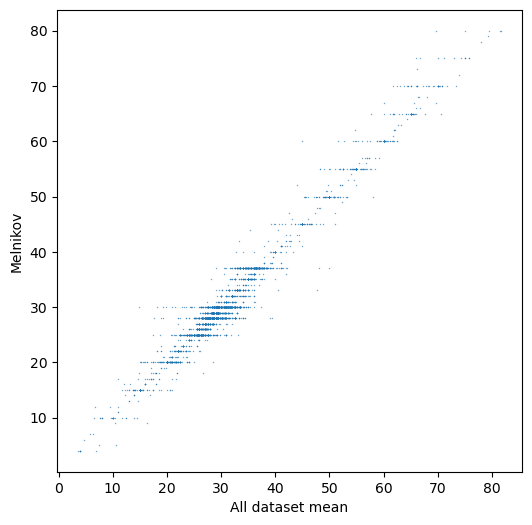

In [29]:
fig, ax = plt.subplots(figsize=(6,6))
sns.scatterplot(y=metrics_df.set_index('uid')['temp'], x=new_match_data.groupby('gtdb_accession').agg({'temp':'mean'})['temp'],
               linewidth=0, alpha=0.65, s=1)
ax.set_ylabel('Melnikov')
ax.set_xlabel('All dataset mean')

In [38]:
corr_data = new_match_data.groupby(['gtdb_accession', 'db']).agg({'temp':'mean', })['temp'].unstack()

<Axes: xlabel='count', ylabel='Count'>

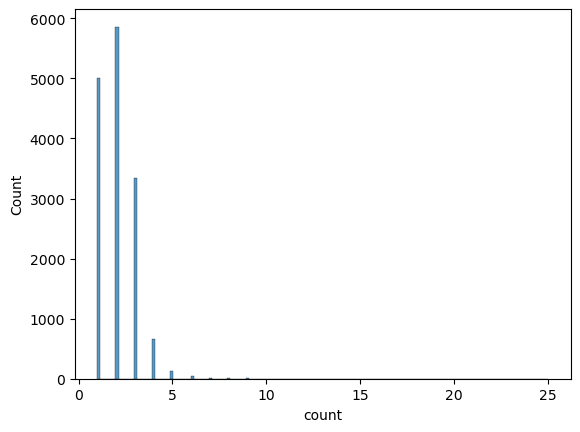

In [41]:
sns.histplot(new_match_data['gtdb_accession'].value_counts())

In [55]:
new_match_data[new_match_data['db'].isin(['corkey', 'melnikov'])].sort_values('gtdb_accession')

,gtdb_accession,db,match_type,original_id,temp
0,GB_GCA_000010565.1,corkey,fuzzy,Pelotomaculum thermopropionicum,45.025689
4,GB_GCA_000012145.1,melnikov,assembly,Rickettsia felis,NaN
5,GB_GCA_000014225.1,melnikov,assembly,Pseudoalteromonas atlantica T6c,23.0
8,GB_GCA_000016765.1,melnikov,assembly,Sphingomonas wittichii RW1,30.0
10,GB_GCA_000017245.1,melnikov,assembly,Actinobacillus succinogenes,30.0
...,...,...,...,...,...
30566,RS_GCF_910593725.1,melnikov,assembly,Candidatus Vallotia tarda,NaN
30567,RS_GCF_910593845.1,melnikov,assembly,Paenibacillus solanacearum,30.0
30574,RS_GCF_914271545.1,melnikov,assembly,Cupriavidus respiraculi,32.0
30587,RS_GCF_937425535.1,melnikov,assembly,Rhodovastum atsumiense,30.0


In [52]:
corr_data[['corkey', 'melnikov']].dropna()

db,corkey,melnikov
gtdb_accession,,
GB_GCA_001048675.1,15.133736,32.0
GB_GCA_001610955.1,44.928826,55.0
GB_GCA_003148465.1,56.5,37.0
GB_GCA_003722315.1,37.300251,70.0
GB_GCA_018853935.1,19.963736,28.0
...,...,...
RS_GCF_900182585.1,45.228275,70.0
RS_GCF_900215245.1,0.0,30.0
RS_GCF_900215515.1,50.095435,70.0


Text(0.5, 0, 'Corkey')

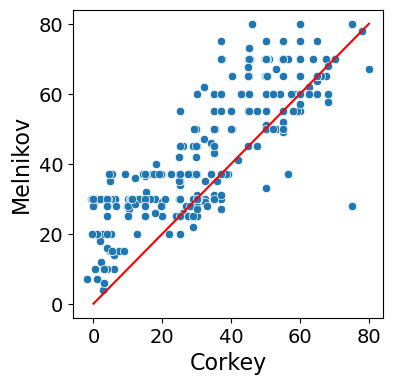

In [56]:
fig, ax = plt.subplots(figsize=(4,4))
sns.scatterplot(data=corr_data, x='corkey', y='melnikov')
plt.plot((0, 80), (0, 80), color='r')
plt.tick_params(labelsize=14)
ax.set_ylabel('Melnikov', fontsize=16)
ax.set_xlabel('Corkey', fontsize=16)

In [30]:
new_temps = new_match_data.groupby('gtdb_accession').agg({'temp':'mean'})['temp']

Text(0.5, 0, 'SASA')

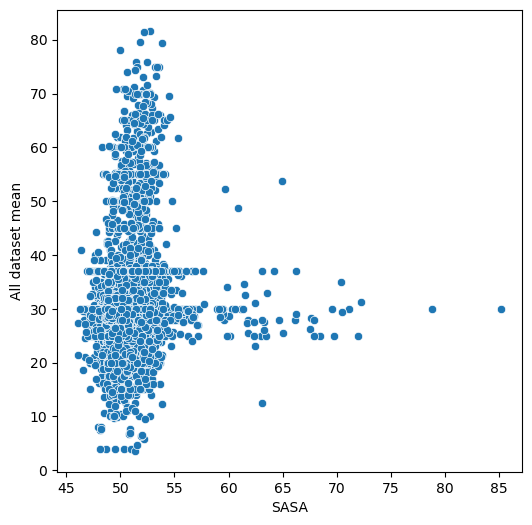

In [31]:
# new correlations
fig, ax = plt.subplots(figsize=(6,6))
sns.scatterplot(x=metrics_df.set_index('uid')['SASA'], y=new_temps)
ax.set_ylabel('All dataset mean')
ax.set_xlabel('SASA')

#### Notes
It does look like using the new temps cleans up some of the discretization

In [35]:
metrics_df['mean_temp'] = metrics_df['uid'].apply(lambda x: new_temps.loc[x] if x in new_temps.index else metrics_df.loc[x, 'temp'])

In [51]:
new_match_data[new_match_data['db'].eq('corkey')].groupby('gtdb_accession').agg({'temp':'mean'})['temp'].to_csv('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/metric_tables/20240410_corkey_save.tsv', sep='\t')

# Saving

In [36]:
secondary_structure.to_csv('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/metric_tables/20240327_ss_save.tsv', sep='\t')

In [37]:
metrics_df.to_csv('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/metric_tables/20240327_metrics_df_save.tsv', sep='\t', index=False)